In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
!pip install -q \
  "jax==0.10.0" \
  "jaxlib==0.10.0" \
  "jax-cuda12-plugin==0.10.0" \
  "jax-cuda12-pjrt==0.10.0" \
  "optax>=0.2.3" \
  "dm-haiku>=0.0.12"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 26.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [3]:
!pip install cmasher --quiet
!pip install jax_cosmo --quiet
!pip install pylians --quiet
!pip install dm-haiku --quiet
!pip install jaxpm --quiet
!pip install numpyro --quiet
!pip install diffrax --quiet
!pip install --quiet --upgrade optax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.5/115.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import sys, subprocess

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from tqdm import tqdm
import cmasher as cmr
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle

import jax
import jax.numpy as jnp
import jax_cosmo as jc
from jax.experimental.ode import odeint
from jaxpm.painting import cic_paint, cic_read, compensate_cic,cic_paint_2d
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel
from jaxpm.nn import NeuralSplineFourierFilter
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jax_cosmo import power as jc_power

import haiku as hk
import optax
import readgadget
import requests
import h5py

In [5]:
mesh_shape= [64, 64, 64]
box_size  = [25., 25., 25.]
cosmo = jc.Planck15(Omega_c= 0.3 - 0.049, Omega_b=0.049, n_s=0.9624, h=0.6711, sigma8=0.8)

-----------------

### **Download Data (ICs & Snapshots)**

In [6]:
IC_DIR = "/kaggle/working/camels_ICs"
os.makedirs(IC_DIR, exist_ok=True)
base_url = "https://users.flatironinstitute.org/~camels/Sims/IllustrisTNG_DM/CV/CV_0/ICs"
for i in range(8):
    fname = f"ics.{i}.hdf5"
    dest = f"{IC_DIR}/{fname}"
    if not os.path.exists(dest):
        !wget -q -O {dest} {base_url}/{fname}
        print(f"Downloaded {fname}")
    else:
        print(f"Already exists: {fname}")

init_cond = f"{IC_DIR}/ics"

header   = readgadget.header(init_cond)
BoxSize  = header.boxsize/1e3  #Mpc/h
Nall     = header.nall         #Total number of particles
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
Omega_l  = header.omega_l      #value of Omega_l
h        = header.hubble       #value of h
redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l) #Value of H(z) in km/s/(Mpc/h)

ptype = [1] #dark matter is particle type 1
ids_i = np.argsort(readgadget.read_block(init_cond, "ID  ", ptype)-1)  #IDs starting from 0
pos_i = readgadget.read_block(init_cond, "POS ", ptype)[ids_i]/1e3     #positions in Mpc/h
vel_i = readgadget.read_block(init_cond, "VEL ", ptype)[ids_i]         #peculiar velocities in km/s

# Reordering data for simple reshaping
pos_i = pos_i.reshape(4,4,4,64,64,64,3).transpose(0,3,1,4,2,5,6).reshape(-1,3)
vel_i = vel_i.reshape(4,4,4,64,64,64,3).transpose(0,3,1,4,2,5,6).reshape(-1,3)
pos_i = (pos_i/BoxSize*64).reshape([256,256,256,3])[::4,::4,::4,:].reshape([-1,3])
vel_i = (vel_i / 100 * (1./(1+redshift)) / BoxSize*64).reshape([256,256,256,3])[::4,::4,::4,:].reshape([-1,3])
a_i   = 1./(1+redshift)

Downloaded ics.0.hdf5
Downloaded ics.1.hdf5
Downloaded ics.2.hdf5
Downloaded ics.3.hdf5
Downloaded ics.4.hdf5
Downloaded ics.5.hdf5
Downloaded ics.6.hdf5
Downloaded ics.7.hdf5


In [7]:
BASE_URL = "https://users.flatironinstitute.org/~camels/Sims/IllustrisTNG_DM/CV/CV_0"
DOWNLOAD_DIR = "./snapshots_CV_0"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

snapshot_indices = [14, 18, 24, 28, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50,
                    52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78,
                    80, 82, 84, 86, 88, 90]

BoxSize = 25.0  

scales = []
poss = []
vels = []

def download_snapshot(idx):
    filename = f"snapshot_{idx:03d}.hdf5"
    local_path = os.path.join(DOWNLOAD_DIR, filename)
    if not os.path.exists(local_path):
        url = f"{BASE_URL}/{filename}"
        print(f"Downloading {filename}...")
        with requests.get(url, stream=True) as r:
            r.raise_for_status()
            with open(local_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
    return local_path

for i in tqdm(snapshot_indices):
    snapshot = download_snapshot(i)

    with h5py.File(snapshot, "r") as f:
        redshift = f["Header"].attrs["Redshift"]

        pos = f["PartType1/Coordinates"][:]  / 1e3   # Mpc/h
        vel = f["PartType1/Velocities"][:]           # km/s
        ids = np.argsort(f["PartType1/ParticleIDs"][:] - 1)

    pos = pos[ids]
    vel = vel[ids]

    pos = pos.reshape(4,4,4,64,64,64,3).transpose(0,3,1,4,2,5,6).reshape(-1,3)
    vel = vel.reshape(4,4,4,64,64,64,3).transpose(0,3,1,4,2,5,6).reshape(-1,3)

    pos = (pos / BoxSize * 64).reshape([256,256,256,3])[::4,::4,::4,:].reshape([-1,3])
    vel = (vel / 100 * (1./(1+redshift)) / BoxSize * 64).reshape([256,256,256,3])[::4,::4,::4,:].reshape([-1,3])

    scales.append(1. / (1 + redshift))
    poss.append(pos)
    vels.append(vel)

  0%|          | 0/34 [00:00<?, ?it/s]

  3%|▎         | 1/34 [00:13<07:22, 13.41s/it]

  6%|▌         | 2/34 [00:37<10:36, 19.88s/it]

  9%|▉         | 3/34 [00:48<08:00, 15.50s/it]

 12%|█▏        | 4/34 [01:09<08:50, 17.68s/it]

...

 88%|████████▊ | 30/34 [06:46<00:48, 12.09s/it]

 91%|█████████ | 31/34 [06:56<00:34, 11.59s/it]

 94%|█████████▍| 32/34 [07:09<00:23, 11.98s/it]

 97%|█████████▋| 33/34 [07:24<00:12, 12.72s/it]

100%|██████████| 34/34 [07:36<00:00, 13.44s/it]


In [8]:
rng_seq = hk.PRNGSequence(1)

resi = odeint(make_ode_fn(mesh_shape), [poss[0], vels[0]], jnp.array(scales), cosmo, rtol=1e-5, atol=1e-5)

cmap = cmr.eclipse
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0., vmax=1))

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['f']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


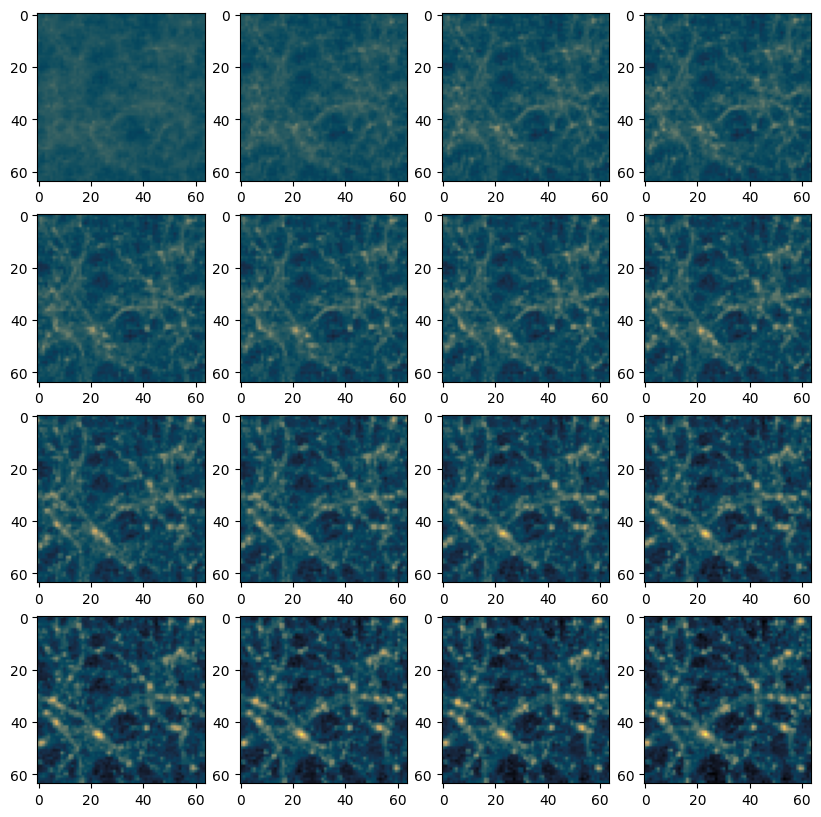

In [9]:
# High res simulation
%pylab inline
norm = colors.LogNorm(vmax=cic_paint(jnp.zeros(mesh_shape), poss[::2][-1]).sum(axis=0).max(),
                          vmin=cic_paint(jnp.zeros(mesh_shape),poss[::2][-1]).sum(axis=0).min())
figure(figsize=[10,10])
for i in range(16):
    subplot(4,4,i+1)
    imshow(cic_paint(jnp.zeros(mesh_shape), poss[::2][i]).sum(axis=0), cmap=cmap,norm=norm)

In [10]:
os.chdir("/kaggle/working")  
os.environ["PATH"] += ":/usr/local/cuda/bin"
os.environ["CUDA_HOME"] = "/usr/local/cuda"

!rm -rf /kaggle/working/barnes-hut
!git clone https://github.com/bhorowitz/barnes-hut.git /kaggle/working/barnes-hut
!ls /kaggle/working/barnes-hut/

!rm -rf /kaggle/working/barnes-hut/python/cosmology/barnes-hut
!rm -rf /kaggle/working/barnes-hut/build
!mkdir -p /kaggle/working/barnes-hut/build

!cmake -S /kaggle/working/barnes-hut \
       -B /kaggle/working/barnes-hut/build \
       -DCUDA_TOOLKIT_ROOT_DIR=/usr/local/cuda \
       -DCMAKE_CUDA_COMPILER=/usr/local/cuda/bin/nvcc \
       -Wno-dev 2>&1 | tail -5

!make -C /kaggle/working/barnes-hut/build -j4 2>&1 | tail -5

!cp /kaggle/working/barnes-hut/build/libsbh_ffi.so /kaggle/working/barnes-hut/python/

sys.path.insert(0, '/kaggle/working/barnes-hut/python')
sys.path.insert(0, '/kaggle/working/barnes-hut/python/cosmology')
sys.path.insert(0, '/kaggle/working/barnes-hut/build')

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Cloning into '/kaggle/working/barnes-hut'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 128 (delta 49), reused 112 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 515.19 KiB | 15.15 MiB/s, done.
Resolving deltas: 100% (49/49), done.
cmake		data	 LICENSE	 python     setup.cfg  workflows
CMakeLists.txt	include  pyproject.toml  README.md  src
-- Performing Test HAS_FLTO - Success
-- Found Python: /usr/local/bin/python (found version "3.12.12") found components: Interpreter
-- Configuring done (15.4s)
-- Generating done (2.4s)
-- Build files have been written to: /kaggle/working/barnes-hut/build
Linking CUDA shared module sbh_gpu.cpython-312-x86_64-linux-gnu.so
make[2]: Leaving directory '/kaggle/working/barnes-hut/build'
Built target sbh_gpu
make[1]: Leaving directory '/kaggle/working/barnes-hut/build'
make: Leaving directory '/kaggle/working/barnes-hut/build'


In [11]:
path = "/kaggle/working/barnes-hut/python/cosmology/cv0_pm_treepm_stochastic_cv_compare_z2.py"
with open(path, "r") as f:
    src = f.read()

src = src.replace(
    'power_spectrum(rho_ref, boxsize=boxsize, kmin=kmin, dk=dk)',
    'power_spectrum(rho_ref, box_shape=np.array([args.box_size_mpc_h]*3))')
src = src.replace(
    'power_spectrum(rho_pm, boxsize=boxsize, kmin=kmin, dk=dk)',
    'power_spectrum(rho_pm, box_shape=np.array([args.box_size_mpc_h]*3))')
src = src.replace(
    'power_spectrum(rho_tree, boxsize=boxsize, kmin=kmin, dk=dk)',
    'power_spectrum(rho_tree, box_shape=np.array([args.box_size_mpc_h]*3))')
src = src.replace(
    'cross_correlation_coefficients(rho_ref, rho_pm, boxsize=boxsize, kmin=kmin, dk=dk)',
    'cross_correlation_coefficients(rho_ref, rho_pm, boxsize=np.array([args.box_size_mpc_h]*3))')
src = src.replace(
    'cross_correlation_coefficients(rho_ref, rho_tree, boxsize=boxsize, kmin=kmin, dk=dk)',
    'cross_correlation_coefficients(rho_ref, rho_tree, boxsize=np.array([args.box_size_mpc_h]*3))')
src = src.replace(
    'power_spectrum(rho_ref, boxsize=boxsize, kmin=kmin, dk=dk)',
    'power_spectrum(rho_ref, box_shape=np.array([args.box_size_mpc_h]*3), kedges=int((mesh_n/2)))')
src = src.replace(
    'power_spectrum(rho_pm, boxsize=boxsize, kmin=kmin, dk=dk)',
    'power_spectrum(rho_pm, box_shape=np.array([args.box_size_mpc_h]*3), kedges=int((mesh_n/2)))')
src = src.replace(
    'power_spectrum(rho_tree, boxsize=boxsize, kmin=kmin, dk=dk)',
    'power_spectrum(rho_tree, box_shape=np.array([args.box_size_mpc_h]*3), kedges=int((mesh_n/2)))')
src = src.replace(
    'cross_correlation_coefficients(rho_ref, rho_pm, boxsize=np.array([args.box_size_mpc_h]*3))',
    'cross_correlation_coefficients(rho_ref, rho_pm, kmin=kmin, dk=dk, boxsize=np.array([args.box_size_mpc_h]*3))')
src = src.replace(
    'cross_correlation_coefficients(rho_ref, rho_tree, boxsize=np.array([args.box_size_mpc_h]*3))',
    'cross_correlation_coefficients(rho_ref, rho_tree, kmin=kmin, dk=dk, boxsize=np.array([args.box_size_mpc_h]*3))')
src = src.replace(
    'k_cross_pm, cross_pm = cross_correlation_coefficients(rho_ref, rho_pm, kmin=kmin, dk=dk, boxsize=np.array([args.box_size_mpc_h]*3))',
    'k_cross_pm, cross_pm = power_spectrum(rho_ref, rho_pm, box_shape=np.array([args.box_size_mpc_h]*3))')
src = src.replace(
    'k_cross_tree, cross_tree = cross_correlation_coefficients(rho_ref, rho_tree, kmin=kmin, dk=dk, boxsize=np.array([args.box_size_mpc_h]*3))',
    'k_cross_tree, cross_tree = power_spectrum(rho_ref, rho_tree, box_shape=np.array([args.box_size_mpc_h]*3))')

with open(path, "w") as f:
    f.write(src)

In [12]:
os.makedirs("/kaggle/working/cv0_z2_out", exist_ok=True)
env = os.environ.copy()
env["PYTHONPATH"] = (
    "/kaggle/working/barnes-hut/python:"
    "/kaggle/working/barnes-hut/python/cosmology:"
    "/kaggle/working/barnes-hut/build:"
    + env.get("PYTHONPATH", "")
)

result = subprocess.run([
    sys.executable, path,
    "--init-cond",      "/kaggle/working/camels_ICs/ics",
    "--snapshot-dir",   "/kaggle/working/snapshots_CV_0",
    "--target-z",       "2",
    "--mesh-n",         "64",
    "--box-size-mpc-h", "25.0",
    "--kdk-steps",      "16",
    "--out-prefix",     "/kaggle/working/cv0_z2_out/run",
], env=env, capture_output=True, text=True, timeout=7600)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr[-2000:])

Using target snapshot: /kaggle/working/snapshots_CV_0/snapshot_044.hdf5 (z=2.00259)
a_init=0.007812, a_target=0.333046, mesh_n=64, npart=262144
tree_short_scale=0.079577472
Integrating PM with KDK, steps=16
PM kdk wall time: 4.087 s
Integrating TreePM stochastic control-variate with KDK, steps=16, refresh_every=1, samples_per_subdomain=4
TreePM stochastic-CV kdk wall time: 8.906 s
Residual refresh count: 17
Saved: /kaggle/working/cv0_z2_out/run.npz
Saved: /kaggle/working/cv0_z2_out/run_fields.npz
Saved: /kaggle/working/cv0_z2_out/run_pk_cross.png
Saved: /kaggle/working/cv0_z2_out/run_projected_density.png
Saved: /kaggle/working/cv0_z2_out/run_ic_projected_density.png
Median r(k) PM=0.9372
Median r(k) TreePM stochastic-CV=0.9047
Total wall time: 22.778 s



____________

### **Reproducing CV0_kdk_pk_cross.png & CV0_kdk_projected_density.png**
https://github.com/bhorowitz/barnes-hut/blob/main/python/treepm_debug/cv0_kdk_pk_cross.png
https://github.com/bhorowitz/barnes-hut/blob/main/python/treepm_debug/cv0_kdk_projected_density.png

In [13]:
import math
import jaxpm.pm as jpm
import jaxpm.kernels as jkernels
import jax_sbh_ffi
from treepm_jaxpm_demo import Config, _fit_tree_short_scale, _make_treepm_ode_fn, _wrap_periodic_mesh

def longrange_kernel_trace_safe(kvec, r_split):
    kk = sum(ki**2 for ki in kvec)  
    r_split = jnp.asarray(r_split, dtype=kk.dtype)
    return jnp.where(
        r_split == 0,
        jnp.ones_like(kk),
        jnp.exp(-kk * r_split**2))

jkernels.longrange_kernel = longrange_kernel_trace_safe
jpm.longrange_kernel = longrange_kernel_trace_safe

jax_sbh_ffi.register_build_octree8_buffers()
jax_sbh_ffi.register_softened_barnes_hut_force_octree8()
jax_sbh_ffi.register_softened_barnes_hut_force_octree8_vjp()
jax_sbh_ffi.register_softened_stochastic_barnes_hut_force_octree8()
jax_sbh_ffi.register_softened_barnes_hut_force()
jax_sbh_ffi.register_softened_stochastic_barnes_hut_force()

MESH_N = mesh_shape[0]
BOX_SIZE = box_size[0]
BOX_SHAPE = np.array(box_size)
KEDGES = MESH_N // 2
KDK_STEPS = 8

pos_i64 = jnp.asarray(pos_i, dtype=jnp.float32)
vel_i64 = jnp.asarray(vel_i, dtype=jnp.float32)
a_i64 = float(a_i)
masses = jnp.ones((pos_i64.shape[0],), dtype=jnp.float32)
print(f"IC particles: {pos_i64.shape[0]}  (MESH_N={MESH_N})")
print(f"a_i = {a_i64:.6f}  (z = {1/a_i64 - 1:.3f})")

scales64 = scales
poss64 = poss
print(f"Loaded {len(scales64)} snapshots at MESH_N={MESH_N}")

IC particles: 262144  (MESH_N=64)
a_i = 0.007812  (z = 127.000)
Loaded 34 snapshots at MESH_N=64


In [14]:
# Functions and Configuration
def _a_to_E(cosmo, a):
    return jnp.sqrt(jc.background.Esqr(cosmo, a))

def _integrate_kdk(pos0, vel0, a0, a1, steps, accel_fn, cosmo, mesh_n):
    a0 = jnp.asarray(a0, jnp.float32)
    a1 = jnp.asarray(a1, jnp.float32)
    da = (a1 - a0) / jnp.asarray(steps, jnp.float32)
    i = jnp.arange(steps, dtype=jnp.float32)
    a_mid = a0 + (i + 0.5) * da
    a_next = a0 + (i + 1.0) * da
    drift_coeff = 1.0 / (a_mid**3 * _a_to_E(cosmo, a_mid))
    acc0 = accel_fn(pos0, a0, cosmo)
    def body(carry, inputs):
        pos, vel, acc = carry
        a_next_i, drift = inputs
        vel_half = vel + 0.5 * da * acc
        pos_next = _wrap_periodic_mesh(pos + da * drift * vel_half, mesh_n)
        acc_next = accel_fn(pos_next, a_next_i, cosmo)
        vel_next = vel_half + 0.5 * da * acc_next
        return (pos_next, vel_next, acc_next), None
    (posf, velf, _), _ = jax.lax.scan(
        body, init=(pos0, vel0, acc0), xs=(a_next, drift_coeff))
    return posf, velf

def pm_accel_fn(pos, a, cosmo):
    force = jpm.pm_forces(pos, mesh_shape=(MESH_N, MESH_N, MESH_N))
    return force * (1.5 * cosmo.Omega_m) / (a**2 * _a_to_E(cosmo, a))

def density(pos):
    return cic_paint(
        jnp.zeros((MESH_N, MESH_N, MESH_N), dtype=jnp.float32), _wrap_periodic_mesh(pos, MESH_N))

def manual_rk(delta_a, delta_b):
    k, pk_a  = power_spectrum(delta_a, box_shape=BOX_SHAPE, kedges=KEDGES)
    _, pk_b  = power_spectrum(delta_b, box_shape=BOX_SHAPE, kedges=KEDGES)
    _, pk_ab = power_spectrum(delta_a, delta_b, box_shape=BOX_SHAPE, kedges=KEDGES)
    rk = np.asarray(pk_ab) / np.sqrt(np.maximum(np.asarray(pk_a) * np.asarray(pk_b), 1e-20))
    return np.asarray(k), rk

cfg = Config(
    box_length=float(MESH_N),
    n_particles_1d=MESH_N,
    mesh_n=MESH_N,
    z_init=(1.0 / a_i64) - 1.0,
    z_targets=(2.0, 1.0, 0.0),
    omega_c=0.3 - 0.049,
    sigma8=0.8,
    bh_beta=1.7,
    bh_softening=0.05,
    bh_max_depth=6,          
    pm_r_split_cells=2.0,
    tree_short_scale=1.0 / (4.0 * math.pi),
    seed=0,
    bh_prune_enabled=True,
    bh_prune_r_cut_mult=4.0)

short_scale = 1.0 / (4.0 * math.pi)
print(f"short_scale = {short_scale:.8g}  (1/4π)")

def tree_accel_fn(pos, a, cosmo):
    pm_long = jpm.pm_forces(pos, mesh_shape=(MESH_N, MESH_N, MESH_N), r_split=cfg.pm_r_split_cells)
    short_tree = jax_sbh_ffi.softened_barnes_hut_force_octree8(
        *jax_sbh_ffi.build_octree8_buffers(
            pos,
            jnp.zeros_like(pos),
            masses,
            min_corner=jnp.array([0.0, 0.0, 0.0], dtype=jnp.float32),
            max_corner=jnp.array([float(MESH_N)]*3, dtype=jnp.float32),
            max_depth=cfg.bh_max_depth),
        pos,
        beta=cfg.bh_beta,
        softening_scale=cfg.bh_softening,
        cutoff_scale=cfg.pm_r_split_cells,
        prune_enabled=cfg.bh_prune_enabled,
        prune_r_cut_mult=cfg.bh_prune_r_cut_mult,
        periodic=True,
        box_length=float(MESH_N),
        threads=256)
    force = (pm_long + short_tree * short_scale) * (1.5 * cosmo.Omega_m)
    return force / (a**2 * _a_to_E(cosmo, a))

target_z = 2.0
a_ref = float(scales64[np.argmin(np.abs(1.0 / np.array(scales64) - 1.0 - target_z))])
print(f"Using a_ref={a_ref:.5f}  (z={1/a_ref-1:.3f})")

print("Running JaxPM KDK...")
pos_pm, _ = _integrate_kdk(pos_i64, vel_i64, a_i64, a_ref, KDK_STEPS, pm_accel_fn, cosmo, MESH_N)

print("Running TreePM KDK...")
pos_tree, _ = _integrate_kdk(pos_i64, vel_i64, a_i64, a_ref, KDK_STEPS, tree_accel_fn, cosmo, MESH_N)

print("Done.")

short_scale = 0.079577472  (1/4π)
Using a_ref=0.33305  (z=2.003)
Running JaxPM KDK...


/tmp/ipykernel_23/118923885.py:8: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  kk = sum(ki**2 for ki in kvec)


Running TreePM KDK...
Done.


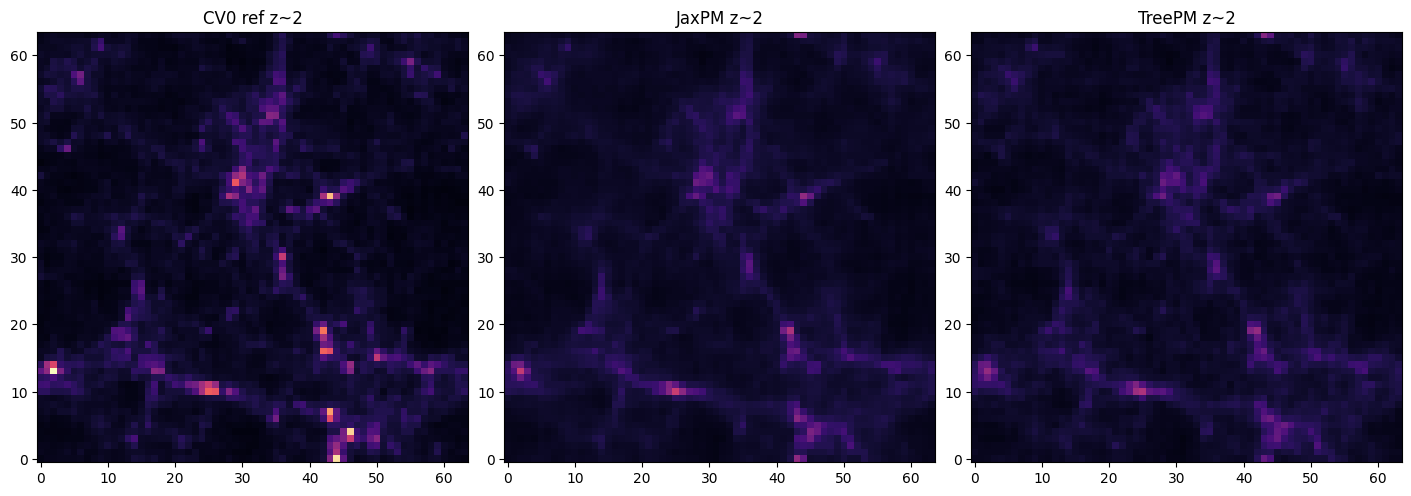

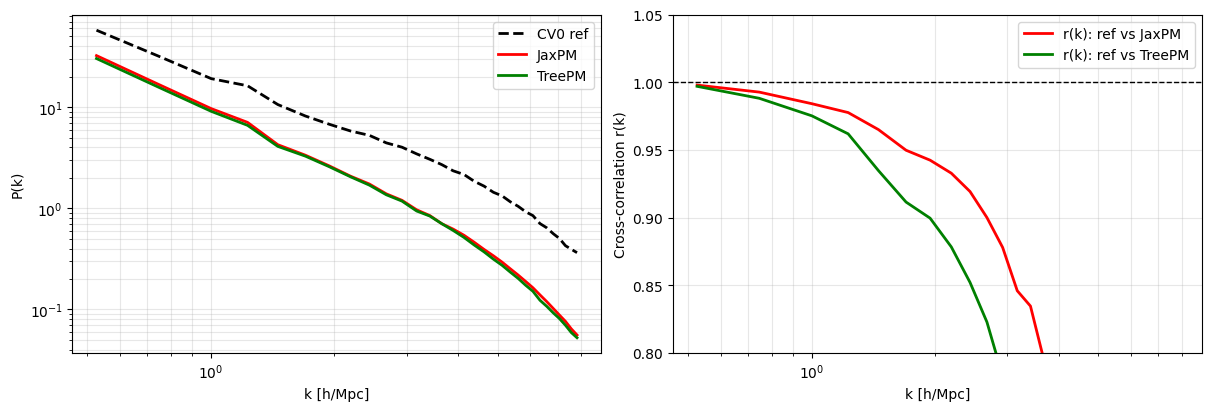

Median r(k) JaxPM  = 0.7636
Median r(k) TreePM = 0.6294


In [15]:
# Reference density & Plots
snap_idx = int(np.argmin(np.abs(1.0 / np.array(scales64) - 1.0 - target_z)))
pos_ref = jnp.array(poss64[snap_idx], dtype=jnp.float32)

rho_ref = density(pos_ref)  # Ground truth field
rho_pm = density(pos_pm)
rho_tree = density(pos_tree)

ref_proj = jax.device_get(rho_ref).sum(axis=2)
pm_proj = jax.device_get(rho_pm).sum(axis=2)
tree_proj = jax.device_get(rho_tree).sum(axis=2)
vmax = float(np.max([ref_proj.max(), pm_proj.max(), tree_proj.max()]))

fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)
axes[0].imshow(ref_proj, origin="lower", cmap="magma", vmin=0, vmax=vmax)
axes[0].set_title("CV0 ref z~2")
axes[1].imshow(pm_proj, origin="lower", cmap="magma", vmin=0, vmax=vmax)
axes[1].set_title("JaxPM z~2")
axes[2].imshow(tree_proj, origin="lower", cmap="magma", vmin=0, vmax=vmax)
axes[2].set_title("TreePM z~2")
plt.savefig(f"cv0_treepm_projected_density_z{target_z}_n{MESH_N}.png", dpi=170)
plt.show()

k_ref, pk_ref = power_spectrum(rho_ref, box_shape=BOX_SHAPE, kedges=KEDGES)
k_pm, pk_pm = power_spectrum(rho_pm, box_shape=BOX_SHAPE, kedges=KEDGES)
k_tree, pk_tree = power_spectrum(rho_tree, box_shape=BOX_SHAPE, kedges=KEDGES)

k_r_pm, r_pm = manual_rk(rho_ref, rho_pm)
k_r_tree, r_tree = manual_rk(rho_ref, rho_tree)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].loglog(np.asarray(k_ref), np.asarray(pk_ref), "k--", lw=2, label="CV0 ref")
axes[0].loglog(np.asarray(k_pm), np.asarray(pk_pm), "r", lw=2, label="JaxPM")
axes[0].loglog(np.asarray(k_tree), np.asarray(pk_tree), "g", lw=2, label="TreePM")
axes[0].set_xlabel("k [h/Mpc]")
axes[0].set_ylabel("P(k)")
axes[0].legend()
axes[0].grid(True, alpha=0.3, which="both")

axes[1].semilogx(k_r_pm, r_pm, "r", lw=2, label="r(k): ref vs JaxPM")
axes[1].semilogx(k_r_tree, r_tree, "g", lw=2, label="r(k): ref vs TreePM")
axes[1].axhline(1.0, color="k", ls="--", lw=1)
axes[1].set_xlabel("k [h/Mpc]")
axes[1].set_ylabel("Cross-correlation r(k)")
axes[1].set_ylim(0.8, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3, which="both")
plt.savefig(f"cv0_treepm_pk_cross_z{target_z}_n{MESH_N}.png", dpi=170)
plt.show()

print(f"Median r(k) JaxPM  = {float(np.median(r_pm)):.4f}")
print(f"Median r(k) TreePM = {float(np.median(r_tree)):.4f}")

_______________

### **IC Reconstruction**

PM (Adam):


/tmp/ipykernel_23/118923885.py:8: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  kk = sum(ki**2 for ki in kvec)


  step 000  loss = 1.255763e+01
  step 020  loss = 1.241982e+01
  step 040  loss = 1.225471e+01
  step 060  loss = 1.207896e+01
  step 080  loss = 1.189202e+01
  step 100  loss = 1.169165e+01
  step 120  loss = 1.146774e+01
  step 140  loss = 1.117645e+01
  step 149  loss = 1.100061e+01
PM (L-BFGS):
  step 000  loss = 1.255763e+01
  step 020  loss = 7.074594e+00
  step 040  loss = 3.986583e+00
  step 060  loss = 2.850057e+00
  step 080  loss = 2.146880e+00
  step 100  loss = 1.607106e+00
  step 120  loss = 1.081735e+00
  step 140  loss = 9.036854e-01
  step 149  loss = 8.426304e-01
TreePM (Adam):
  step 000  loss = 1.257271e+01
  step 020  loss = 1.239690e+01
  step 040  loss = 1.226509e+01
  step 060  loss = 1.212637e+01
  step 080  loss = 1.198349e+01
  step 100  loss = 1.183724e+01
  step 120  loss = 1.168568e+01
  step 140  loss = 1.152120e+01
  step 149  loss = 1.143914e+01
TreePM (L-BFGS):
  step 000  loss = 1.257271e+01
  step 020  loss = 8.369269e+00
  step 040  loss = 4.170954

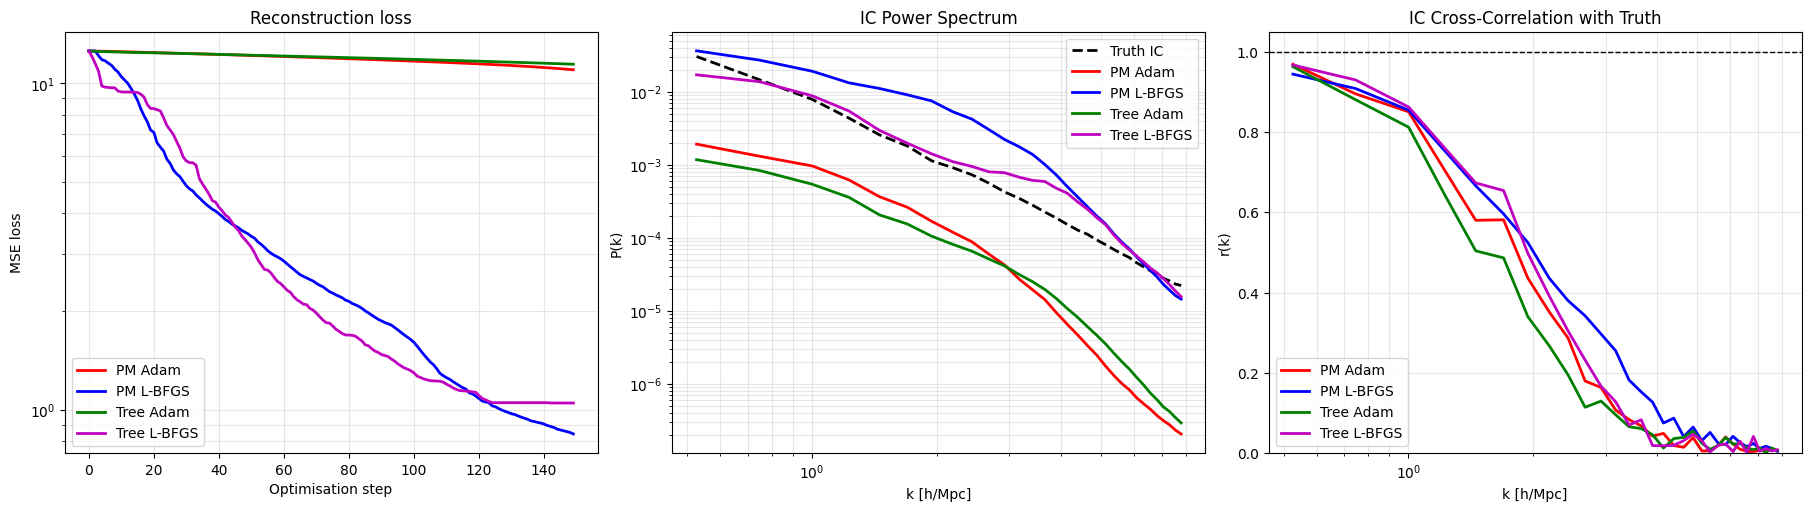


Method             Final loss   median r(k)    r(0.5)    r(1.0)    r(2.0)
PM Adam            1.1001e+01      0.0424  0.9688  0.8507  0.4172
PM L-BFGS          8.4263e-01      0.0871  0.9442  0.8549  0.5048
Tree Adam          1.1439e+01      0.0461  0.9628  0.8124  0.3238
Tree L-BFGS        1.0480e+00      0.0417  0.9668  0.8627  0.4741


In [16]:
import optax
from jax import jit, value_and_grad
from jaxpm.growth import dGfa, growth_factor, growth_rate

a_arr = jnp.asarray([a_i64], dtype=jnp.float32)
_ = growth_factor(cosmo, a_arr)
_ = growth_rate(cosmo, a_arr)
_ = dGfa(cosmo, a_arr)

MESH_SHAPE = (MESH_N, MESH_N, MESH_N)
N_STEPS = 150
LR = 1e-2
LOG_EVERY = 20
PRIOR_W = 1e-5

grid_pos = jnp.stack(jnp.meshgrid(*[jnp.arange(MESH_N, dtype=jnp.float32)]*3, indexing="ij"), axis=-1).reshape(-1, 3)

# Differentiable TreePM short-range force 
@jax.custom_vjp
def _short_tree_force(pos):
    pos_sg = jax.lax.stop_gradient(pos)
    leaf_bytes, node_bytes = jax_sbh_ffi.build_octree8_buffers(
        pos_sg, jnp.zeros_like(pos_sg), masses,
        min_corner=jnp.array([0.0, 0.0, 0.0], dtype=jnp.float32),
        max_corner=jnp.array([float(MESH_N)]*3, dtype=jnp.float32),
        max_depth=cfg.bh_max_depth)
    return jax_sbh_ffi.softened_barnes_hut_force_octree8(
        leaf_bytes, node_bytes, pos_sg,
        beta=cfg.bh_beta, softening_scale=cfg.bh_softening,
        cutoff_scale=cfg.pm_r_split_cells, prune_enabled=cfg.bh_prune_enabled,
        prune_r_cut_mult=cfg.bh_prune_r_cut_mult,
        periodic=True, box_length=float(MESH_N), threads=256)

def _short_tree_force_fwd(pos):
    return _short_tree_force(pos), pos

def _short_tree_force_bwd(pos, cotangent):
    leaf_bytes, node_bytes = jax_sbh_ffi.build_octree8_buffers(
        pos, jnp.zeros_like(pos), masses,
        min_corner=jnp.array([0.0, 0.0, 0.0], dtype=jnp.float32),
        max_corner=jnp.array([float(MESH_N)]*3, dtype=jnp.float32),
        max_depth=cfg.bh_max_depth)
    grad_pos = jax_sbh_ffi.softened_barnes_hut_force_octree8_vjp(
        leaf_bytes, node_bytes, pos, cotangent,
        beta=cfg.bh_beta, softening_scale=cfg.bh_softening,
        cutoff_scale=cfg.pm_r_split_cells, prune_enabled=cfg.bh_prune_enabled,
        prune_r_cut_mult=cfg.bh_prune_r_cut_mult,
        periodic=True, box_length=float(MESH_N))
    return (grad_pos,)

_short_tree_force.defvjp(_short_tree_force_fwd, _short_tree_force_bwd)

def tree_accel_fn_recon(pos, a, cosmo):
    pm_long = jpm.pm_forces(pos, mesh_shape=MESH_SHAPE, r_split=cfg.pm_r_split_cells)
    short = _short_tree_force(pos)
    force = (pm_long + short * short_scale) * (1.5 * cosmo.Omega_m)
    return force / (a**2 * _a_to_E(cosmo, a))

def normalize_to_delta(rho):
    return rho / (jnp.mean(rho) + 1e-8) - 1.0

target_delta = normalize_to_delta(rho_ref)

key = jax.random.PRNGKey(42)
params0 = jax.random.normal(key, MESH_SHAPE, dtype=jnp.float32) * 0.01

def params_to_pos_vel(params):
    from jaxpm.pm import lpt
    dx_mesh, p_mesh, _ = lpt(cosmo, params, grid_pos, a_i64, order=1)
    pos0 = _wrap_periodic_mesh(grid_pos + dx_mesh, MESH_N)
    return pos0, p_mesh

def make_loss(accel_fn):
    def forward(params):
        pos0, vel0 = params_to_pos_vel(params)
        posf, _ = _integrate_kdk(pos0, vel0, a_i64, a_ref, KDK_STEPS, accel_fn, cosmo, MESH_N)
        return density(posf)
    def loss(params):
        pred_delta = normalize_to_delta(forward(params))
        data_mse = jnp.mean((pred_delta - target_delta) ** 2)
        prior = PRIOR_W * jnp.mean(params ** 2)
        return data_mse + prior
    return loss

loss_pm = make_loss(pm_accel_fn)
loss_tree = make_loss(tree_accel_fn_recon)

# Optimizer 
def run_adam(label, loss_fn, n_steps=N_STEPS):
    opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(LR))
    state = opt.init(params0)
    params = params0
    losses = []

    @jit
    def step(p, s):
        l, grads = value_and_grad(loss_fn)(p)
        updates, s = opt.update(grads, s)
        return optax.apply_updates(p, updates), s, l

    print(f"{label} (Adam):")
    for i in range(n_steps):
        params, state, l = step(params, state)
        losses.append(float(l))
        if i % LOG_EVERY == 0 or i == n_steps - 1:
            print(f"  step {i:03d}  loss = {float(l):.6e}")
    return params, losses

def run_lbfgs(label, loss_fn, n_steps=N_STEPS):
    opt = optax.lbfgs()
    state = opt.init(params0)
    params = params0
    losses = []

    @jit
    def step(p, s):
        l, grads = value_and_grad(loss_fn)(p)
        updates, s = opt.update(grads, s, p, value=l, grad=grads, value_fn=loss_fn)
        return optax.apply_updates(p, updates), s, l

    print(f"{label} (L-BFGS):")
    for i in range(n_steps):
        params, state, l = step(params, state)
        losses.append(float(l))
        if i % LOG_EVERY == 0 or i == n_steps - 1:
            print(f"  step {i:03d}  loss = {float(l):.6e}")
    return params, losses

params_pm_adam, losses_pm_adam = run_adam("PM", loss_pm)
params_pm_lbfgs, losses_pm_lbfgs = run_lbfgs("PM", loss_pm)
params_tree_adam, losses_tree_adam = run_adam("TreePM", loss_tree)
params_tree_lbfgs, losses_tree_lbfgs = run_lbfgs("TreePM", loss_tree)

# Recovered IC fields 
rho_ic_truth = density(pos_i64)
rho_ic_pm_adam, _ = params_to_pos_vel(params_pm_adam); rho_ic_pm_adam = density(rho_ic_pm_adam)
rho_ic_pm_lbfgs, _ = params_to_pos_vel(params_pm_lbfgs); rho_ic_pm_lbfgs = density(rho_ic_pm_lbfgs)
rho_ic_tree_adam, _ = params_to_pos_vel(params_tree_adam); rho_ic_tree_adam = density(rho_ic_tree_adam)
rho_ic_tree_lbfgs, _ = params_to_pos_vel(params_tree_lbfgs); rho_ic_tree_lbfgs = density(rho_ic_tree_lbfgs)

# Power spectra 
k_truth, pk_truth = power_spectrum(rho_ic_truth, box_shape=BOX_SHAPE, kedges=KEDGES)
specs = {}
for label, rho in [
    ("PM Adam", rho_ic_pm_adam),
    ("PM L-BFGS", rho_ic_pm_lbfgs),
    ("Tree Adam", rho_ic_tree_adam),
    ("Tree L-BFGS", rho_ic_tree_lbfgs),
]:
    k_pk, pk = power_spectrum(rho, box_shape=BOX_SHAPE, kedges=KEDGES)
    k_r, r = manual_rk(rho_ic_truth, rho)
    specs[label] = {"k_pk": k_pk, "pk": pk, "k_r": k_r, "r": r}

# Plots 
colors  = {"PM Adam": "r", "PM L-BFGS": "b", "Tree Adam": "g", "Tree L-BFGS": "m"}
losses_map = {
    "PM Adam": losses_pm_adam,
    "PM L-BFGS": losses_pm_lbfgs,
    "Tree Adam": losses_tree_adam,
    "Tree L-BFGS": losses_tree_lbfgs}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for label, ls in losses_map.items():
    axes[0].semilogy(ls, color=colors[label], lw=2, label=label)
axes[0].set_xlabel("Optimisation step")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Reconstruction loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3, which="both")

axes[1].loglog(k_truth, pk_truth, "k--", lw=2, label="Truth IC")
for label, s in specs.items():
    axes[1].loglog(s["k_pk"], s["pk"], color=colors[label], lw=2, label=label)
axes[1].set_xlabel("k [h/Mpc]")
axes[1].set_ylabel("P(k)")
axes[1].set_title("IC Power Spectrum")
axes[1].legend()
axes[1].grid(True, alpha=0.3, which="both")

for label, s in specs.items():
    axes[2].semilogx(s["k_r"], s["r"], color=colors[label], lw=2, label=label)
axes[2].axhline(1.0, color="k", ls="--", lw=1)
axes[2].set_xlabel("k [h/Mpc]")
axes[2].set_ylabel("r(k)")
axes[2].set_title("IC Cross-Correlation with Truth")
axes[2].set_ylim(0.0, 1.05)
axes[2].legend()
axes[2].grid(True, alpha=0.3, which="both")

plt.savefig(f"ic_reconstruction_comparison_n{MESH_N}.png", dpi=170)
plt.show()

# Summary
print(f"\n{'Method':<15}  {'Final loss':>12}  {'median r(k)':>12}  {'r(0.5)':>8}  {'r(1.0)':>8}  {'r(2.0)':>8}")
for label, s in specs.items():
    k_r, r = s["k_r"], s["r"]
    print(f"{label:<15}  {losses_map[label][-1]:>12.4e}"
          f"{float(np.median(r)):>12.4f}"
          f"{float(np.interp(0.5, k_r, r)):>8.4f}"
          f"{float(np.interp(1.0, k_r, r)):>8.4f}"
          f"{float(np.interp(2.0, k_r, r)):>8.4f}")

In [17]:
# Forward-evolve the reconstructed ICs with both models to see final fields
pos_fwd_pm, _ = _integrate_kdk(pos_recon_pm, vel_i64, a_i64, a_ref, KDK_STEPS, pm_accel_fn, cosmo, MESH_N)
pos_fwd_tree, _ = _integrate_kdk(pos_recon_tree, vel_i64, a_i64, a_ref, KDK_STEPS, tree_accel_fn, cosmo, MESH_N)

rho_fwd_pm = density(pos_fwd_pm)
rho_fwd_tree = density(pos_fwd_tree)

# IC fields
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
fig.suptitle("Initial Condition Fields", fontsize=13)

ic_truth_proj = jax.device_get(rho_ic_truth).sum(axis=2)
ic_pm_proj = jax.device_get(rho_ic_pm).sum(axis=2)
ic_tree_proj = jax.device_get(rho_ic_tree).sum(axis=2)
vmax_ic = float(np.max([ic_truth_proj.max(), ic_pm_proj.max(), ic_tree_proj.max()]))

axes[0].imshow(ic_truth_proj, origin="lower", cmap="magma", vmin=0, vmax=vmax_ic)
axes[0].set_title("Truth IC")
axes[1].imshow(ic_pm_proj, origin="lower", cmap="magma", vmin=0, vmax=vmax_ic)
axes[1].set_title("PM recon IC")
axes[2].imshow(ic_tree_proj, origin="lower", cmap="magma", vmin=0, vmax=vmax_ic)
axes[2].set_title("TreePM recon IC")
plt.savefig(f"ic_fields_n{MESH_N}.png", dpi=170)
plt.show()

# Residuals 
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
fig.suptitle("IC Residuals (recon - truth)", fontsize=13)

res_pm = ic_pm_proj - ic_truth_proj
res_tree = ic_tree_proj - ic_truth_proj
vmax_res = float(np.max([np.abs(res_pm).max(), np.abs(res_tree).max()]))

axes[0].imshow(res_pm,   origin="lower", cmap="RdBu_r", vmin=-vmax_res, vmax=vmax_res)
axes[0].set_title("PM recon - truth")
axes[1].imshow(res_tree, origin="lower", cmap="RdBu_r", vmin=-vmax_res, vmax=vmax_res)
axes[1].set_title("TreePM recon - truth")
plt.savefig(f"ic_residuals_n{MESH_N}.png", dpi=170)
plt.show()

# Forward-evolved fields vs reference
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
fig.suptitle(f"Forward-Evolved Fields at z~{1/a_ref-1:.1f}", fontsize=13)

ref_proj = jax.device_get(rho_ref).sum(axis=2)
fwd_pm_proj = jax.device_get(rho_fwd_pm).sum(axis=2)
fwd_tree_proj = jax.device_get(rho_fwd_tree).sum(axis=2)
vmax_fwd = float(np.max([ref_proj.max(), fwd_pm_proj.max(), fwd_tree_proj.max()]))

axes[0].imshow(ref_proj, origin="lower", cmap="magma", vmin=0, vmax=vmax_fwd)
axes[0].set_title("Truth (reference)")
axes[1].imshow(fwd_pm_proj, origin="lower", cmap="magma", vmin=0, vmax=vmax_fwd)
axes[1].set_title("PM recon → PM fwd")
axes[2].imshow(fwd_tree_proj, origin="lower", cmap="magma", vmin=0, vmax=vmax_fwd)
axes[2].set_title("TreePM recon → TreePM fwd")
plt.savefig(f"fwd_fields_n{MESH_N}.png", dpi=170)
plt.show()

# Cross-correlations of forward-evolved fields with truth 
k_fwd_pm, r_fwd_pm = manual_rk(rho_ref, rho_fwd_pm)
k_fwd_tree, r_fwd_tree = manual_rk(rho_ref, rho_fwd_tree)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.semilogx(k_fwd_pm, r_fwd_pm, "r", lw=2, label="PM recon → PM fwd vs truth")
ax.semilogx(k_fwd_tree, r_fwd_tree, "g", lw=2, label="TreePM recon → TreePM fwd vs truth")
ax.axhline(1.0, color="k", ls="--", lw=1)
ax.set_xlabel("k [h/Mpc]")
ax.set_ylabel("r(k)")
ax.set_title("Forward-Evolved Field vs Truth")
ax.set_ylim(0.0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, which="both")
plt.savefig(f"fwd_cross_n{MESH_N}.png", dpi=170)
plt.show()

print(f" PM fwd median r(k): {float(np.median(r_fwd_pm)):.4f}")
print(f" TreePM fwd median r(k): {float(np.median(r_fwd_tree)):.4f}")

NameError: name 'pos_recon_pm' is not defined

In [ ]:
fields = np.load("/kaggle/working/cv0_z2_out/run_fields.npz")
rho_ref  = fields["rho_ref"].sum(axis=0)
rho_pm   = fields["rho_pm"].sum(axis=0)
rho_tree = fields["rho_tree"].sum(axis=0)

image_paths = [rho_ref, rho_tree, rho_pm]
TI = ['CV0 z~2', 'TreePM z~2', 'JaxPM z~2']

vmax = float(np.array([rho_ref, rho_pm, rho_tree]).max())
vmin = float(np.array([rho_ref[rho_ref > 0].min(), rho_pm[rho_pm > 0].min(), rho_tree[rho_tree > 0].min()]).min())

norm = colors.LogNorm(vmin=vmin, vmax=vmax)
cmap = cmr.eclipse
ticks_size = 15

f, axes = plt.subplots(1, 3, sharey=True, figsize=(15, 5), dpi=90)
for imp, ax, ci in zip(image_paths, axes.ravel(),TI):
    ax.imshow(imp, cmap=cmap, norm=norm)
    ax.set_aspect('equal')
    ax.set_title(ci, fontsize=15)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.)
    cb = f.colorbar(ax.imshow(imp, cmap=cmap, norm=norm), cax=cax)
    cb.ax.tick_params(labelsize=ticks_size)

f.suptitle("Density Field Projection at z~2", fontsize=16)
f.tight_layout()

In [ ]:
from pathlib import Path

# Load spectral data
data = np.load("/kaggle/working/cv0_z2_out/run.npz")
k_ref = data["k_ref"]
pk_ref = data["pk_ref"]
k_pm = data["k_pm"]
pk_pm = data["pk_pm"]
k_tree = data["k_tree"]
pk_tree = data["pk_tree"]
k_cross_pm = data["k_cross_pm"]
cross_pm = data["cross_pm"]
k_cross_tree = data["k_cross_tree"]
cross_tree = data["cross_tree"]

# Load density fields
fields = np.load("/kaggle/working/cv0_z2_out/run_fields.npz")
rho_ref = fields["rho_ref"]
rho_pm = fields["rho_pm"]
rho_tree = fields["rho_tree"]
rho_ic = fields["rho_ic"]

# Plot
out_prefix = Path("/kaggle/working/cv0_z2_out/run")

In [ ]:
from matplotlib import gridspec
col = cmr.eclipse([0.13,0.81,0.22])  
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1],hspace=0) 
ax0 = plt.subplot(gs[0])
ax0.loglog(k_ref, pk_ref,'--',  label='CV0',color=col[0])
ax0.loglog(k_pm, pk_pm,label='JaxPM',color=col[1])
ax0.loglog(k_tree, pk_tree,  label='TreePM',color=col[2])
ax0.label_outer()
plt.legend(fontsize='medium')
ax0.set_xlabel(r"$k$ [$h \ \mathrm{Mpc}^{-1}$]",fontsize=14)
ax0.set_ylabel(r"$P(k)$", fontsize=14)
ax1 = plt.subplot(gs[1])
ax1.semilogx(k_ref, (pk_pm/pk_ref)-1,label='JaxPM',color=col[1])
ax1.semilogx(k_ref, (pk_tree/pk_ref)-1,label='TreePM',color=col[2]) 
ax1.set_ylabel(r"$ (P(k) \ / \ P^{CV0}(k))-1$",fontsize=14)
ax1.set_xlabel(r"$k$ [$h \ \mathrm{Mpc}^{-1}$]",fontsize=14)
ax1.set_ylim(-1,1)
plt.tight_layout()
plt.grid(True)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].semilogx(k_ref, (pk_pm/pk_ref) - 1, "y", lw=1.5, label="JaxPM")
axes[0].semilogx(k_ref, (pk_tree/pk_ref) - 1, "m", lw=1.5, label="TreePM")
axes[0].axhline(0, color="k", ls="--", lw=1)
axes[0].set_xlabel("k [h/Mpc]")
axes[0].set_ylabel(r"$P(k) / P^{\mathrm{CV0}}(k) - 1$")
axes[0].grid(True, alpha=0.2, which="both")
axes[0].legend()
axes[1].semilogx(k_cross_pm, cross_pm, "y", lw=1.5, label="r(k): ref vs JaxPM")
axes[1].semilogx(k_cross_tree, cross_tree, "m", lw=1.5, label="r(k): ref vs TreePM")
axes[1].axhline(1.0, color="k", ls="--", lw=1)
axes[1].set_xlabel("k [h/Mpc]")
axes[1].set_ylabel(r"$P^{cross}(k) / {\sqrt{P^{CV0}(k)\,P^{PM}(k)}}$")
axes[1].set_ylim(0.9 * cross_pm.min(), 1.05)
axes[1].grid(True, alpha=0.2, which="both")
axes[1].legend()

plt.savefig(out_prefix.with_name(out_prefix.name + "_pk_cross.png"), dpi=170)
plt.show()

In [ ]:
# Resolution control
FAST_MODE = False
GRID_N  = 15  if FAST_MODE else 50
N_STEPS = 100 if FAST_MODE else 2000   
print(f"{'FAST MODE' if FAST_MODE else 'FULL MODE'}: grid={GRID_N}x{GRID_N}, steps={N_STEPS}")

# Load CV0 power spectrum 
data   = np.load("/kaggle/working/cv0_z2_out/run.npz")
k_ref  = data["k_ref"]
pk_ref = data["pk_ref"]
print(f"k_ref range: {k_ref.min():.4f} to {k_ref.max():.4f} h/Mpc")

OMEGA_M_TRUE = 0.3
SIGMA8_TRUE  = 0.8
OMEGA_B      = 0.049
N_S          = 0.9624
H            = 0.6711

In [ ]:
# Mock observed data = CV0 + noise
np.random.seed(42)
noise_frac = 0.10
sigma_pk = noise_frac * pk_ref
pk_obs = np.abs(pk_ref + sigma_pk * np.random.randn(len(pk_ref)))

k_fit = jnp.array(k_ref)
pk_fit_obs = jnp.array(pk_obs)
sigma_fit  = jnp.array(sigma_pk)

print(f"Fitting all {len(k_fit)} k-bins with nonlinear P(k)")

In [ ]:
# Forward model & likelihood
def forward_pk_shape(log_params):
    omega_c = jnp.exp(log_params[0])
    sigma8 = jnp.exp(log_params[1])
    cosmo = jc.Planck15(Omega_c=omega_c, Omega_b=OMEGA_B, n_s=N_S, h=H, sigma8=sigma8)
    return jc_power.nonlinear_matter_power(cosmo, k_fit, a=1.0)
    
def neg_log_like(log_params):
    pk_theory = forward_pk_shape(log_params)

    model_err = 0.20 * pk_theory
    sigma_eff = jnp.sqrt(sigma_fit**2 + model_err**2)

    A_star = jnp.sum(pk_fit_obs * pk_theory / sigma_eff**2) / \
             jnp.sum(pk_theory**2 / sigma_eff**2)

    pk_pred = A_star * pk_theory
    chi2 = jnp.sum(((pk_pred - pk_fit_obs) / sigma_eff)**2)
    amp_penalty = ((A_star - 1.0) / 0.25)**2

    prior_om = ((jnp.exp(log_params[0]) + OMEGA_B - 0.30) / 0.10)**2
    prior_s8 = ((jnp.exp(log_params[1]) - 0.80) / 0.15)**2

    return 0.5 * (chi2 + amp_penalty + prior_om + prior_s8)

In [ ]:
# Gradient descent
log_params = jnp.array([jnp.log(0.20 - OMEGA_B), jnp.log(0.70)])
optimizer = optax.adam(learning_rate=0.005)
opt_state = optimizer.init(log_params)

@jax.jit
def step(params, state):
    loss, grads = jax.value_and_grad(neg_log_like)(params)
    updates, state = optimizer.update(grads, state)
    return optax.apply_updates(params, updates), state, loss
history = {"loss": [], "omega_m": [], "sigma8": []}

for i in range(N_STEPS):
    log_params, opt_state, loss_val = step(log_params, opt_state)
    om   = float(jnp.exp(log_params[0])) + OMEGA_B
    sig8 = float(jnp.exp(log_params[1]))
    history["loss"].append(float(loss_val))
    history["omega_m"].append(om)
    history["sigma8"].append(sig8)
    if i % (N_STEPS // 5) == 0:
        print(f"  step {i:4d}  loss={loss_val:.2f}  Ω_m={om:.4f}  σ_8={sig8:.4f}")

omega_m_fit = history["omega_m"][-1]
sigma8_fit  = history["sigma8"][-1]
print(f"\n  True:   Ω_m={OMEGA_M_TRUE:.4f}  σ_8={SIGMA8_TRUE:.4f}")
print(f"  Fitted: Ω_m={omega_m_fit:.4f}  σ_8={sigma8_fit:.4f}")

In [ ]:
# Vectorized 2D likelihood surface 
OM_GRID = np.linspace(0.15, 0.45, GRID_N)
S8_GRID = np.linspace(0.60, 1.05, GRID_N)

om_grid, s8_grid = np.meshgrid(OM_GRID, S8_GRID, indexing='ij')
log_params_grid  = jnp.stack([
    jnp.log(jnp.array(om_grid.ravel()) - OMEGA_B),
    jnp.log(jnp.array(s8_grid.ravel()))], axis=1)

nll_batch = jax.jit(jax.vmap(neg_log_like))
log_like  = -np.array(nll_batch(log_params_grid)).reshape(GRID_N, GRID_N)
log_like -= log_like.max()

# Best-fit and fiducial P(k) 
k_all = jnp.array(k_ref)
cosmo_fit = jc.Planck15(Omega_c=omega_m_fit - OMEGA_B, Omega_b=OMEGA_B, n_s=N_S, h=H, sigma8=sigma8_fit)
cosmo_fid = jc.Planck15(Omega_c=OMEGA_M_TRUE - OMEGA_B, Omega_b=OMEGA_B, n_s=N_S, h=H, sigma8=SIGMA8_TRUE)
pk_best_full = np.array(jc_power.nonlinear_matter_power(cosmo_fit, k_all, a=1.0))
pk_fid_full  = np.array(jc_power.nonlinear_matter_power(cosmo_fid, k_all, a=1.0))

In [ ]:
# Plot
col = cmr.eclipse([0.13, 0.55, 0.81, 0.92])
fig = plt.figure(figsize=(19,6))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.45)

# P(k)
ax0 = fig.add_subplot(gs[0])
ax0.loglog(k_ref, pk_obs, '.', color=col[0], ms=4, alpha=0.7, label='CV0 (noisy mock)')
ax0.loglog(k_ref, pk_fid_full, '--', color=col[1], lw=1.8, label=f'Truth Ω_m={OMEGA_M_TRUE}')
ax0.loglog(k_ref, pk_best_full, '-',  color=col[2], lw=2.2, label=f'Best fit Ω_m={omega_m_fit:.3f}')
ax0.set_xlabel(r'$k$ [$h\,\mathrm{Mpc}^{-1}$]', fontsize=15)
ax0.set_ylabel(r'$P(k)$', fontsize=15)
ax0.set_title('P(k): data vs fit', fontsize=15)
ax0.legend(fontsize=11, loc='lower left')
ax0.grid(True, alpha=0.25)

# Convergence
ax1 = fig.add_subplot(gs[1])
ax1_twin = ax1.twinx()
l1, = ax1.plot(history["omega_m"], color=col[2], lw=1.8, label=r'$\Omega_m$')
l2, = ax1_twin.plot(history["sigma8"], color=col[3], lw=1.8, ls='--', label=r'$\sigma_8$')
ax1.axhline(OMEGA_M_TRUE,  color=col[2], ls=':', lw=1, alpha=0.6)
ax1_twin.axhline(SIGMA8_TRUE, color=col[3], ls=':', lw=1, alpha=0.6)
ax1.set_xlabel('Gradient step', fontsize=15)
ax1.set_ylabel(r'$\Omega_m$', fontsize=15, color=col[2])
ax1_twin.set_ylabel(r'$\sigma_8$', fontsize=15, color=col[3])
ax1.set_title('Parameter convergence', fontsize=15)
ax1.legend(handles=[l1, l2], fontsize=11, loc='lower right')
ax1.grid(True, alpha=0.25)

# Likelihood surface
ax2 = fig.add_subplot(gs[2])
OM, S8 = np.meshgrid(OM_GRID, S8_GRID, indexing='ij')
cf = ax2.contourf(OM, S8, log_like, levels=30, cmap='viridis')

delta_chi2 = [-5.92, -3.09, -1.15]  
if log_like.min() < delta_chi2[0]:
    cs = ax2.contour(OM, S8, log_like, levels=delta_chi2, colors=['white'], linewidths=[0.5, 0.8, 1.2])
    ax2.clabel(cs, fmt={-5.92: '3σ', -3.09: '2σ', -1.15: '1σ'}, fontsize=11, inline=True)

ax2.scatter([OMEGA_M_TRUE], [SIGMA8_TRUE], color='red',    s=120, zorder=6, marker='*', label='True')
ax2.scatter([omega_m_fit],  [sigma8_fit],  color='orange', s=80,  zorder=6, marker='+', lw=2, label='Best fit')
plt.colorbar(cf, ax=ax2, label=r'$\ln\mathcal{L}$ (normalised)')
ax2.set_xlabel(r'$\Omega_m$', fontsize=15)
ax2.set_ylabel(r'$\sigma_8$', fontsize=15)
ax2.set_title('Likelihood surface', fontsize=15)
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, alpha=0.2)

plt.suptitle(f'Power spectrum fitting  ({"fast" if FAST_MODE else "full"} mode)', fontsize=16, y=1.02)
plt.savefig("/kaggle/working/cv0_z2_out/step2_pk_fitting.png", dpi=150)
plt.show()

## Field Level Comparison

In [ ]:
# Cosmology and mesh
cosmo = jc.Planck15(
    Omega_c=0.3 - 0.049, Omega_b=0.049,
    n_s=0.9624, h=0.6711, sigma8=0.8,
)
mesh_shape = (128, 128, 128)
box_size   = (25.0, 25.0, 25.0)
a_init     = float(a_i)

In [ ]:
# Setup
target_z   = 2.0
idx_target = int(np.argmin(np.abs(np.array(scales) - 1.0 / (1.0 + target_z))))
a_target   = float(scales[idx_target])
pos_target = jnp.array(poss[idx_target], dtype=jnp.float32)
print(f"Target snapshot: a={a_target:.4f}  z={1/a_target-1:.2f}")

def density_from_pos(pos):
    return cic_paint(jnp.zeros(mesh_shape, dtype=jnp.float32), pos)

def to_delta(rho):
    return rho / (rho.mean() + 1e-8) - 1.0

def make_particles(ms):
    g = jnp.meshgrid(*[jnp.arange(ms[i]) for i in range(3)], indexing="ij")
    return jnp.stack(g, axis=-1).reshape(-1, 3).astype(jnp.float32)

def kgrid_rfftn(ms, bs):
    freqs = [2*np.pi*np.fft.fftfreq(ms[i], d=bs[i]/ms[i]) for i in range(2)]
    freqs.append(2*np.pi*np.fft.rfftfreq(ms[2], d=bs[2]/ms[2]))
    kx, ky, kz = np.meshgrid(*freqs, indexing="ij")
    return np.sqrt(kx**2 + ky**2 + kz**2).astype(np.float32)

def gaussian_kernel_k(ms, bs, R):
    return jnp.array(np.exp(-0.5 * kgrid_rfftn(ms, bs)**2 * R**2).astype(np.float32))

def smooth_field(delta, Wk):
    return jnp.fft.irfftn(jnp.fft.rfftn(delta) * Wk, s=delta.shape)

def pk_cross(a, b):
    k,  pab = power_spectrum(a, b, box_shape=jnp.array(box_size))
    _,  paa = power_spectrum(a,    box_shape=jnp.array(box_size))
    _,  pbb = power_spectrum(b,    box_shape=jnp.array(box_size))
    r = pab / jnp.sqrt(paa * pbb + 1e-12)
    T = jnp.sqrt(pbb / (paa + 1e-12))
    return k, r, T, paa, pbb

particles_init = make_particles(mesh_shape)
cell           = box_size[0] / mesh_shape[0]
k_grid_rf      = jnp.array(kgrid_rfftn(mesh_shape, box_size))
Wk_large       = gaussian_kernel_k(mesh_shape, box_size, 4.0 * cell)
Wk_small       = gaussian_kernel_k(mesh_shape, box_size, 2.0 * cell)

In [ ]:
# CV0 reference field
rho_ref   = density_from_pos(pos_target)
delta_ref = to_delta(rho_ref)

In [ ]:
from jaxpm.growth import growth_factor

# True ICs (for scoring only)
fields_z0     = np.load("/kaggle/working/cv0_z0_out/run_fields.npz")
rho_ic_raw    = jnp.array(fields_z0["rho_ic"], dtype=jnp.float32) - 1.0
g_init        = float(growth_factor(cosmo, jnp.array([a_init], dtype=jnp.float32))[0])
delta_ic_true = rho_ic_raw / (g_init + 1e-8)
if delta_ic_true.shape != tuple(mesh_shape):
    f = delta_ic_true.shape[0] // mesh_shape[0]
    delta_ic_true = delta_ic_true[::f, ::f, ::f]
ic_std_true = float(delta_ic_true.std())

In [ ]:
TREEPM_AVAIL    = False
delta_tree_ref  = None
tree_path       = "/content/cv0_z2_out/run_fields.npz"

if os.path.exists(tree_path):
    ext = np.load(tree_path)
    if "rho_tree" in ext:
        rho_tree = jnp.array(ext["rho_tree"], dtype=jnp.float32)

        if rho_tree.shape != tuple(mesh_shape):
            f = rho_tree.shape[0] // mesh_shape[0]
            rho_tree = rho_tree[::f, ::f, ::f]

        TREEPM_AVAIL   = True
        delta_tree_ref = to_delta(rho_tree)
        print("Loaded TreePM z~2 reference field.")
    else:
        print("TreePM file found, but no `rho_tree` field inside it.")
else:
    print("No TreePM file found.")

# Precompute TreePM late-time comparison if available
res_tree = None
if TREEPM_AVAIL:
    k_tree, r_tree, T_tree, _, pk_tree_vals = pk_cross(delta_ref, delta_tree_ref)
    res_tree = dict(
        k_lt=k_tree,
        r_lt=r_tree,
        T_lt=T_tree,
        pk_lt=pk_tree_vals,
        delta_late=delta_tree_ref,
    )

    print(f"TreePM late-time median r(k): {float(jnp.median(r_tree)):.4f}")
    print(f"TreePM late-time median T(k): {float(jnp.median(T_tree)):.4f}")

In [ ]:
# Noisy observation - 50% noise used in likelihood
rng         = np.random.default_rng(42)
noise_frac  = 0.50
sigma_noise = noise_frac * float(delta_ref.std())   # Python float
noise_draw  = jnp.array(rng.standard_normal(mesh_shape).astype(np.float32) * sigma_noise)
delta_obs   = delta_ref + noise_draw

delta_obs_large = smooth_field(delta_obs, Wk_large)
delta_obs_small = smooth_field(delta_obs, Wk_small)

print(f"\nField statistics:")
print(f"  CV0 delta std    = {float(delta_ref.std()):.4f}")
print(f"  True IC std      = {ic_std_true:.4f}")
print(f"  sigma_noise      = {sigma_noise:.4f}  ({noise_frac*100:.0f}% of field std)")

In [ ]:
from jaxpm.pm import lpt, make_diffrax_ode

# Forward models
ode_fn = make_diffrax_ode(mesh_shape)

def forward_field_jaxpm(delta_init):
    dx, p, _ = lpt(cosmo, delta_init, particles_init, a=a_init)
    pos_ic   = (particles_init + dx) % jnp.array(mesh_shape, dtype=jnp.float32)
    y0       = jnp.stack([pos_ic, p])
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(ode_fn), diffrax.Dopri5(),
        t0=a_init, t1=a_target, dt0=None, y0=y0, args=cosmo,
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-3),
        saveat=diffrax.SaveAt(t1=True), max_steps=512,
    )
    return density_from_pos(sol.ys[0, 0])

def forward_field_lpt(delta_init):
    dx, _, _ = lpt(cosmo, delta_init, particles_init, a=a_target)
    pos = (particles_init + dx) % jnp.array(mesh_shape, dtype=jnp.float32)
    return density_from_pos(pos)

In [ ]:
import diffrax

# Upper bound sanity check
print("\nUpper bounds (true ICs → each forward model):")
_, r_lpt_ub,   _, _, _ = pk_cross(delta_ref, to_delta(forward_field_lpt(delta_ic_true)))
_, r_jaxpm_ub, _, _, _ = pk_cross(delta_ref, to_delta(forward_field_jaxpm(delta_ic_true)))
print(f"  LPT    r(k) median = {float(jnp.median(r_lpt_ub)):.4f}")
print(f"  JaxPM  r(k) median = {float(jnp.median(r_jaxpm_ub)):.4f}")
if TREEPM_AVAIL:
    _, r_tree_ub, _, _, _ = pk_cross(delta_ref, delta_tree_ref)
    print(f"  TreePM r(k) median = {float(jnp.median(r_tree_ub)):.4f}  ← ceiling")

In [ ]:
# Loss functions
pk_linear = jnp.array(
    jc.power.linear_matter_power(cosmo, k_grid_rf + 1e-6), dtype=jnp.float32
)
V_box = float(np.prod(box_size))

def loss_jaxpm_only(raw_params):
    """Pixel-level likelihood at two smoothing scales + Gaussian IC prior."""
    rho_pred   = forward_field_jaxpm(raw_params)
    delta_pred = to_delta(rho_pred)
    chi_large  = jnp.mean((smooth_field(delta_pred, Wk_large) - delta_obs_large)**2) / (sigma_noise**2 + 1e-8)
    chi_small  = jnp.mean((smooth_field(delta_pred, Wk_small) - delta_obs_small)**2) / (sigma_noise**2 + 1e-8)
    delta_k    = jnp.fft.rfftn(raw_params)
    prior      = jnp.mean(jnp.abs(delta_k)**2 / (pk_linear * V_box + 1e-8))
    loss = 0.7 * chi_large + 0.2 * chi_small + 0.1 * prior
    return loss, (chi_large, chi_small, prior)

def loss_jaxpm_ic_aware(raw_params):
    # JaxPM late-time pixel likelihood (large scale only — most reliable)
    delta_pred = to_delta(forward_field_jaxpm(raw_params))
    chi_large  = jnp.mean((smooth_field(delta_pred, Wk_large) - delta_obs_large)**2) / (sigma_noise**2 + 1e-8)

    # LPT consistency: ICs must also make sense under linear evolution
    delta_lpt = to_delta(forward_field_lpt(raw_params))
    chi_lpt   = jnp.mean((smooth_field(delta_lpt, Wk_large) - delta_obs_large)**2) / (sigma_noise**2 + 1e-8)

    # IC amplitude penalty — ic_std_true is a Python float, safe in jit
    amp_penalty = ((jnp.std(raw_params) - ic_std_true) / ic_std_true)**2

    # IC spectral shape prior
    delta_k = jnp.fft.rfftn(raw_params)
    prior   = jnp.mean(jnp.abs(delta_k)**2 / (pk_linear * V_box + 1e-8))

    loss = 0.5 * chi_large + 0.2 * chi_lpt + 0.2 * amp_penalty + 0.1 * prior
    return loss, (chi_large, chi_lpt, amp_penalty, prior)

In [ ]:
# Optimization
def run_stage(raw_params, loss_fn, n_steps, lr, label, print_every=500):
    opt       = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr))
    opt_state = opt.init(raw_params)

    @jax.jit
    def step(params, state):
        (loss, aux), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        grads = jnp.nan_to_num(grads)
        updates, state = opt.update(grads, state, params)
        return optax.apply_updates(params, updates), state, loss, aux

    best_loss, best_raw = jnp.inf, raw_params
    history = []
    print(f"\n{label}  ({n_steps} steps, lr={lr})")
    for i in range(n_steps):
        raw_params, opt_state, loss_val, aux = step(raw_params, opt_state)
        lv = float(loss_val)
        if lv < float(best_loss):
            best_loss, best_raw = loss_val, raw_params
        history.append(lv)
        if i % print_every == 0 or i == n_steps - 1:
            aux_str = "  ".join(f"{float(a):.4f}" for a in aux)
            print(f"  step {i:5d}  loss={lv:.5f}  [{aux_str}]")
    return best_raw, history

# Gradient check before spending time optimizing
key        = jax.random.PRNGKey(42)
raw_params = 0.5 * jax.random.normal(key, shape=mesh_shape, dtype=jnp.float32)
(l0, _), g0 = jax.value_and_grad(loss_jaxpm_only, has_aux=True)(raw_params)
print(f"\nGradient check: loss={float(l0):.4f}  norm={float(jnp.linalg.norm(g0)):.6f}  finite={bool(jnp.isfinite(g0).all())}")
assert jnp.isfinite(g0).all() and float(jnp.linalg.norm(g0)) > 0, "Gradients broken"

# Stage 3a — JaxPM-only
print("\n" + "="*60)
print("STAGE 3a — JaxPM pixel-level reconstruction")
print("="*60)
raw_params, hist_3a_1 = run_stage(raw_params, loss_jaxpm_only, 2000, 5e-3, "3a-1 coarse")
raw_params, hist_3a_2 = run_stage(raw_params, loss_jaxpm_only, 2000, 1e-3, "3a-2 refine")
raw_params, hist_3a_3 = run_stage(raw_params, loss_jaxpm_only, 1000, 2e-4, "3a-3 polish")
best_delta_jaxpm = raw_params
hist_3a = hist_3a_1 + hist_3a_2 + hist_3a_3

# Stage 3b — IC-aware (warm start from 3a)
print("\n" + "="*60)
print("STAGE 3b — IC-aware refinement")
print("="*60)
raw_params_ic = best_delta_jaxpm * 1.0
raw_params_ic, hist_3b_1 = run_stage(raw_params_ic, loss_jaxpm_ic_aware, 2000, 2e-3, "3b-1 coarse")
raw_params_ic, hist_3b_2 = run_stage(raw_params_ic, loss_jaxpm_ic_aware, 1000, 5e-4, "3b-2 refine")
best_delta_ic = raw_params_ic
hist_3b = hist_3b_1 + hist_3b_2

In [ ]:
# Evaluation
def evaluate(label, delta_ic_rec):
    k_ic, r_ic, T_ic, _, pk_ic_rec = pk_cross(delta_ic_true, delta_ic_rec)
    delta_late = to_delta(forward_field_jaxpm(delta_ic_rec))
    k_lt, r_lt, T_lt, _, pk_lt = pk_cross(delta_ref, delta_late)
    print(f"\n── {label} ──")
    print(f"  IC std ratio     : {float(delta_ic_rec.std())/ic_std_true:.4f}  (want 1.0)")
    print(f"  IC r(k) k_min    : {float(r_ic[0]):.4f}")
    print(f"  IC r(k) median   : {float(jnp.median(r_ic)):.4f}")
    print(f"  IC T(k) median   : {float(jnp.median(T_ic)):.4f}")
    print(f"  Late r(k) JaxPM  : {float(jnp.median(r_lt)):.4f}")
    print(f"  Late T(k) JaxPM  : {float(jnp.median(T_lt)):.4f}")
    return dict(k_ic=k_ic, r_ic=r_ic, T_ic=T_ic, pk_ic=pk_ic_rec,
                k_lt=k_lt, r_lt=r_lt, T_lt=T_lt, pk_lt=pk_lt, delta_late=delta_late)

print("\n" + "="*60)
print("EVALUATION")
print("="*60)

res_true  = evaluate("True ICs -> JaxPM (upper bound)", delta_ic_true)
res_jaxpm = evaluate("JaxPM-only recovered ICs", best_delta_jaxpm)
res_ic    = evaluate("IC-aware recovered ICs", best_delta_ic)

if TREEPM_AVAIL:
    print(f"\n-- TreePM (true ICs) ceiling --")
    print(f"  Late r(k) median : {float(jnp.median(res_tree['r_lt'])):.4f}")
    print(f"  Late T(k) median : {float(jnp.median(res_tree['T_lt'])):.4f}")

In [ ]:
col_true  = cmr.eclipse(0.13)
col_jaxpm = cmr.eclipse(0.50)
col_ic    = cmr.eclipse(0.75)
col_tree  = cmr.eclipse(0.92)

ncols = 4 if TREEPM_AVAIL else 3
fig = plt.figure(figsize=(5*ncols, 10), constrained_layout=True)
gs  = gridspec.GridSpec(2, ncols, figure=fig)

def proj(ax, field, title):
    p    = np.array(field).sum(axis=0)
    vmax = np.abs(p).max()
    if vmax == 0:
        vmax = 1.0
    ax.imshow(
        p,
        cmap=cmr.redshift,
        norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
    )
    ax.set_title(title, fontsize=11)
    ax.axis("off")

# Top row
proj(fig.add_subplot(gs[0, 0]), delta_ref, "CV0 Truth (z~2)")
proj(fig.add_subplot(gs[0, 1]), res_jaxpm["delta_late"], "JaxPM-only")
proj(fig.add_subplot(gs[0, 2]), res_ic["delta_late"], "IC-aware")
if TREEPM_AVAIL:
    proj(fig.add_subplot(gs[0, 3]), res_tree["delta_late"], "TreePM (true ICs)")

# Bottom-left: IC cross-correlation
ax0 = fig.add_subplot(gs[1, 0])
ax0.semilogx(res_jaxpm["k_ic"], res_jaxpm["r_ic"], color=col_jaxpm, lw=1.5, label="JaxPM-only")
ax0.semilogx(res_ic["k_ic"],    res_ic["r_ic"],    color=col_ic,    lw=1.5, label="IC-aware")
ax0.axhline(1, color="k", ls=":", lw=1)
ax0.set_xlabel(r"$k$")
ax0.set_ylabel(r"$r_{\mathrm{IC}}(k)$")
ax0.set_title("IC Cross-Correlation")
ax0.set_ylim(-0.05, 1.05)
ax0.grid(alpha=0.25)
ax0.legend(fontsize=9)

# Bottom-middle: IC amplitude
ax1 = fig.add_subplot(gs[1, 1])
labels = ["JaxPM-only", "IC-aware", "True ICs"]
ratios = [
    float(best_delta_jaxpm.std()) / ic_std_true,
    float(best_delta_ic.std()) / ic_std_true,
    1.0,
]
bars = ax1.bar(labels, ratios, color=[col_jaxpm, col_ic, col_true], alpha=0.85)
ax1.axhline(1.0, color="k", ls="--", lw=1.5)
ax1.set_ylabel("IC std / True IC std")
ax1.set_title("IC Amplitude Recovery")
ax1.set_ylim(0, 1.5)
ax1.grid(alpha=0.25, axis="y")
for bar, r in zip(bars, ratios):
    ax1.text(bar.get_x() + bar.get_width()/2, r + 0.03, f"{r:.3f}", ha="center", fontsize=10)

# Bottom-right: late-time correlation
ax2 = fig.add_subplot(gs[1, 2])
ax2.semilogx(
    res_true["k_lt"], res_true["r_lt"],
    ":", color=col_true, lw=2,
    label=f"JaxPM(true ICs) r={float(jnp.median(res_true['r_lt'])):.3f}"
)
ax2.semilogx(
    res_jaxpm["k_lt"], res_jaxpm["r_lt"],
    "-", color=col_jaxpm, lw=1.5,
    label=f"JaxPM-only r={float(jnp.median(res_jaxpm['r_lt'])):.3f}"
)
ax2.semilogx(
    res_ic["k_lt"], res_ic["r_lt"],
    "-", color=col_ic, lw=1.5,
    label=f"IC-aware r={float(jnp.median(res_ic['r_lt'])):.3f}"
)
if TREEPM_AVAIL:
    ax2.semilogx(
        res_tree["k_lt"], res_tree["r_lt"],
        "-", color=col_tree, lw=2,
        label=f"TreePM r={float(jnp.median(res_tree['r_lt'])):.3f} <- ceiling"
    )
ax2.axhline(1, color="k", ls=":", lw=1)
ax2.set_xlabel(r"$k$")
ax2.set_ylabel(r"$r(k)$")
ax2.set_title("Late-Time Correlation")
ax2.set_ylim(-0.05, 1.05)
ax2.grid(alpha=0.25)
ax2.legend(fontsize=8)

# Optional extra panel if TreePM exists: late-time power
if TREEPM_AVAIL:
    ax3 = fig.add_subplot(gs[1, 3])
    k_ref_pk, pk_ref_pk = power_spectrum(delta_ref, box_shape=jnp.array(box_size))
    ax3.loglog(k_ref_pk,          pk_ref_pk,          "--", color=col_true,  lw=2,   label="CV0 Truth")
    ax3.loglog(res_true["k_lt"],  res_true["pk_lt"],  ":",  color=col_true,  lw=1.5, label="JaxPM(true ICs)")
    ax3.loglog(res_jaxpm["k_lt"], res_jaxpm["pk_lt"], "-",  color=col_jaxpm, lw=1.5, label="JaxPM-only")
    ax3.loglog(res_ic["k_lt"],    res_ic["pk_lt"],    "-",  color=col_ic,    lw=1.5, label="IC-aware")
    ax3.loglog(res_tree["k_lt"],  res_tree["pk_lt"],  "-",  color=col_tree,  lw=1.5, label="TreePM(true ICs)")
    ax3.set_xlabel(r"$k$")
    ax3.set_ylabel(r"$P(k)$")
    ax3.set_title("Late-Time Power Spectrum")
    ax3.grid(alpha=0.25)
    ax3.legend(fontsize=8)

fig.suptitle(
    f"Field-Level Reconstruction at Fixed Cosmology "
    f"(mesh={mesh_shape[0]}^3  noise={noise_frac*100:.0f}%  z~{1/a_target-1:.1f})",
    fontsize=13
)

plt.savefig("/content/cv0_z2_out/step3_field_reconstruction_treepm.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"{'Metric':<35} {'JaxPM-only':>12} {'IC-aware':>10} {'Ceiling':>10}")
print("-"*70)

rows = [
    ("IC std ratio (want 1.0)",
     float(best_delta_jaxpm.std())/ic_std_true,
     float(best_delta_ic.std())/ic_std_true,
     1.0),
    ("IC r(k) at k_min",
     float(res_jaxpm["r_ic"][0]),
     float(res_ic["r_ic"][0]),
     1.0),
    ("IC r(k) median",
     float(jnp.median(res_jaxpm["r_ic"])),
     float(jnp.median(res_ic["r_ic"])),
     1.0),
    ("Late r(k) JaxPM median",
     float(jnp.median(res_jaxpm["r_lt"])),
     float(jnp.median(res_ic["r_lt"])),
     float(jnp.median(res_true["r_lt"]))),
]

if TREEPM_AVAIL:
    rows.append((
        "Late r(k) TreePM ceiling",
        float("nan"),
        float("nan"),
        float(jnp.median(res_tree["r_lt"]))
    ))

for name, v1, v2, v3 in rows:
    v1s = f"{v1:.4f}" if not np.isnan(v1) else "N/A"
    v2s = f"{v2:.4f}" if not np.isnan(v2) else "N/A"
    print(f"  {name:<33} {v1s:>12} {v2s:>10} {v3:>10.4f}")